# ABSA Assessment 2 — Full Pipeline Notebook
**Student:** Saugat Poudel (s395696) | **Unit:** PRT597 NLP | **Due:** April 17, 2026

## Overview
Aspect-Based Sentiment Analysis (ABSA) on the SemEval-2014 Task 4 Laptop dataset (Pontiki et al., 2014).

| Task | Description |
|------|-------------|
| Task 1 | Data Loading & Exploration |
| Task 2 | Data Preprocessing |
| Task 3 | Baseline: TF-IDF + Logistic Regression |
| Task 4 | BERT Fine-tuned Model |
| Task 5 | Evaluation & Human Testing |
| Task 6 | Aspect Extraction |

> **Colab tip:** Runtime → Change runtime type → T4 GPU for faster BERT training.

In [1]:
# Cell 1: Install packages (run first on Colab)
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'transformers', 'torch', 'nltk', 'tqdm'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('All packages ready!')

All packages ready!


In [2]:
# Cell 2: Imports
import os, re, warnings
import xml.etree.ElementTree as ET
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt',                      quiet=True)
nltk.download('punkt_tab',                  quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
os.makedirs('data',    exist_ok=True)

print('Imports successful!')

Imports successful!


In [3]:
# Cell 3: Device setup
import torch

try:
    import google.colab
    IN_COLAB = True
    print('Running on Google Colab')
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    IN_COLAB = False
    print('Running locally')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU detected — BERT training will be slow (use Colab T4 GPU).')

Running on Google Colab
Mounted at /content/drive
Using device: cuda
GPU: Tesla T4


---
## Task 1: Data Loading & Exploration

Parse SemEval-2014 Task 4 XML files (Pontiki et al., 2014) and generate dataset statistics and charts.

In [4]:
# Cell 4a: Download SemEval-2014 Task 4 Laptop dataset
# =====================================================
# Training data from YaxinCui/ABSADataset
# Test data (GOLD STANDARD) from akkarimi/BERT-For-ABSA
#
# Why 'gold standard'?
# The SemEval shared task released test data in two phases:
#   Phase A: raw sentences only (no aspect/polarity labels) — for participants to predict
#   Gold:    the complete test set WITH ground-truth aspect terms and polarity labels
# We need the gold file because it contains the true labels we evaluate our model against.
# Without it, we'd have test sentences but no way to measure accuracy.

import requests

URLS = {
    'data/laptops_train.xml': [
        'https://raw.githubusercontent.com/YaxinCui/ABSADataset/main/SemEval2014Task4/train/laptops_train.xml',
    ],
    'data/laptops_test_gold.xml': [
        # Primary: akkarimi/BERT-For-ABSA (official gold annotations)
        'https://raw.githubusercontent.com/akkarimi/BERT-For-ABSA/master/ae/official_data/Laptops_Test_Gold.xml',
        # Fallback: LCFS-BERT repo (same file, different host)
        'https://raw.githubusercontent.com/HieuPhan33/LCFS-BERT/master/semeval14/Laptops_Test_Gold.xml',
    ],
}

os.makedirs('data', exist_ok=True)

for filepath, url_list in URLS.items():
    if os.path.exists(filepath):
        print(f'[\u2713] {filepath} already exists, skipping.')
        continue
    downloaded = False
    for url in url_list:
        try:
            print(f'[\u2193] Downloading {filepath}...')
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            with open(filepath, 'w', encoding='utf-8') as f:
                f.write(resp.text)
            print(f'[\u2713] Saved {filepath} ({len(resp.text):,} chars)')
            downloaded = True
            break
        except Exception as e:
            print(f'[\u2717] Failed from {url.split("/")[4]}: {e}')
    if not downloaded:
        raise RuntimeError(f'Could not download {filepath} from any source!')

print('\nDataset files ready on disk.')


[↓] Downloading data/laptops_train.xml...
[✓] Saved data/laptops_train.xml (687,142 chars)
[↓] Downloading data/laptops_test_gold.xml...
[✓] Saved data/laptops_test_gold.xml (178,748 chars)

Dataset files ready on disk.


In [5]:
# Cell 4: Parse XML + Load data
def parse_semeval_xml(filepath):
    """Parse SemEval-2014 ABSA XML into a pandas DataFrame."""
    tree = ET.parse(filepath)
    root = tree.getroot()
    data = []
    for sentence in root.findall('.//sentence'):
        sent_id = sentence.get('id')
        text    = sentence.find('text').text
        at_node = sentence.find('aspectTerms')
        if at_node is not None:
            for at in at_node.findall('aspectTerm'):
                data.append({
                    'sentence_id': sent_id,
                    'text':        text,
                    'aspect_term': at.get('term'),
                    'polarity':    at.get('polarity'),
                    'from':        int(at.get('from')),
                    'to':          int(at.get('to')),
                })
        else:
            data.append({
                'sentence_id': sent_id, 'text': text,
                'aspect_term': None, 'polarity': None,
                'from': None, 'to': None,
            })
    return pd.DataFrame(data)

# Load from CSV if available, else parse XML
if os.path.exists('data/laptop_train.csv') and os.path.exists('data/laptop_test.csv'):
    train_df = pd.read_csv('data/laptop_train.csv')
    test_df  = pd.read_csv('data/laptop_test.csv')
    print('Loaded from existing CSV files.')
else:
    train_df = parse_semeval_xml('data/laptops_train.xml')
    test_df  = parse_semeval_xml('data/laptops_test_gold.xml')
    train_df.to_csv('data/laptop_train.csv', index=False)
    test_df.to_csv('data/laptop_test.csv',   index=False)
    print('Parsed XML and saved to CSV.')

train_asp = train_df[train_df['aspect_term'].notna()].copy()
test_asp  = test_df[test_df['aspect_term'].notna()].copy()

print(f'Train: {len(train_df)} rows ({len(train_asp)} with aspects)')
print(f'Test : {len(test_df)} rows ({len(test_asp)} with aspects)')
train_df.head(3)

Parsed XML and saved to CSV.
Train: 3915 rows (2358 with aspects)
Test : 1032 rows (654 with aspects)


,sentence_id,text,aspect_term,polarity,from,to
0,2339,I charge it at night and skip taking the cord ...,cord,neutral,41.0,45.0
1,2339,I charge it at night and skip taking the cord ...,battery life,positive,74.0,86.0
2,812,I bought a HP Pavilion DV4-1222nr laptop and h...,None,None,NaN,NaN


In [6]:
# Cell 5: Dataset statistics
print('=' * 65)
print('DATASET STATISTICS')
print('=' * 65)

rows = [
    ('Total rows',                   len(train_df),                              len(test_df)),
    ('Rows with aspect annotations', len(train_asp),                             len(test_asp)),
    ('Rows without aspects',         len(train_df) - len(train_asp),             len(test_df) - len(test_asp)),
    ('Unique sentences',             train_df['text'].nunique(),                 test_df['text'].nunique()),
    ('Unique aspect terms (raw)',    train_asp['aspect_term'].nunique(),          test_asp['aspect_term'].nunique()),
    ('Unique aspects (lowercased)', train_asp['aspect_term'].str.lower().nunique(), test_asp['aspect_term'].str.lower().nunique()),
]

print(f'\n  {"Metric":<45} {"Train":>8} {"Test":>8}')
print(f'  {"-"*45} {"-"*8} {"-"*8}')
for metric, tr, te in rows:
    print(f'  {metric:<45} {tr:>8} {te:>8}')

print('\nPolarity Distribution:')
print(f'\n  {"Polarity":<12} {"Train":>6} {"Train%":>8} {"Test":>6} {"Test%":>8}')
print(f'  {"-"*12} {"-"*6} {"-"*8} {"-"*6} {"-"*8}')
train_counts = train_asp['polarity'].value_counts()
test_counts  = test_asp['polarity'].value_counts()
for pol in ['positive', 'negative', 'neutral', 'conflict']:
    tr_n = train_counts.get(pol, 0)
    te_n = test_counts.get(pol, 0)
    tr_p = tr_n / len(train_asp) * 100
    te_p = te_n / len(test_asp) * 100
    print(f'  {pol:<12} {tr_n:>6} {tr_p:>7.1f}% {te_n:>6} {te_p:>7.1f}%')

DATASET STATISTICS

  Metric                                           Train     Test
  --------------------------------------------- -------- --------
  Total rows                                        3915     1032
  Rows with aspect annotations                      2358      654
  Rows without aspects                              1557      378
  Unique sentences                                  3033      800
  Unique aspect terms (raw)                         1042      419
  Unique aspects (lowercased)                        955      393

Polarity Distribution:

  Polarity      Train   Train%   Test    Test%
  ------------ ------ -------- ------ --------
  positive        987    41.9%    341    52.1%
  negative        866    36.7%    128    19.6%
  neutral         460    19.5%    169    25.8%
  conflict         45     1.9%     16     2.4%


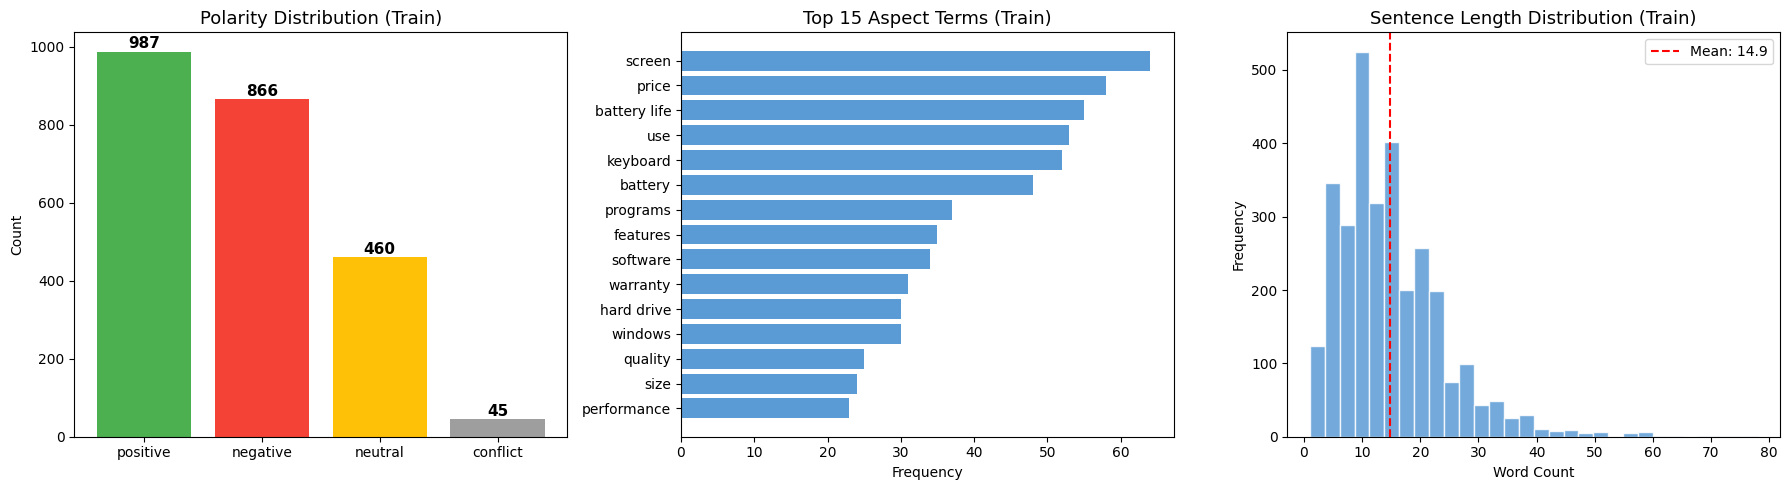

[OK] Saved: outputs/eda_charts.png


In [7]:
# Cell 6: EDA charts
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Polarity distribution
color_map = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FFC107', 'conflict': '#9E9E9E'}
counts = train_asp['polarity'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[color_map.get(p, '#999') for p in counts.index])
axes[0].set_title('Polarity Distribution (Train)', fontsize=13)
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8, str(val), ha='center', fontsize=11, fontweight='bold')

# Chart 2: Top 15 aspect terms
top15 = train_asp['aspect_term'].str.lower().value_counts().head(15)
axes[1].barh(top15.index[::-1], top15.values[::-1], color='#5B9BD5')
axes[1].set_title('Top 15 Aspect Terms (Train)', fontsize=13)
axes[1].set_xlabel('Frequency')

# Chart 3: Sentence length distribution
train_df['word_count'] = train_df['text'].str.split().str.len()
unique_sents = train_df.drop_duplicates(subset='text')
mean_wc = unique_sents['word_count'].mean()
axes[2].hist(unique_sents['word_count'], bins=30, color='#5B9BD5', edgecolor='white', alpha=0.85)
axes[2].axvline(mean_wc, color='red', linestyle='--', label=f'Mean: {mean_wc:.1f}')
axes[2].set_title('Sentence Length Distribution (Train)', fontsize=13)
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Saved: outputs/eda_charts.png')

In [8]:
# Cell 7: Polarity by top aspects + quality checks
print('TOP 10 ASPECTS — POLARITY BREAKDOWN')
print('=' * 65)
train_asp = train_asp.copy()
train_asp['aspect_lower'] = train_asp['aspect_term'].str.lower()
top10 = train_asp['aspect_lower'].value_counts().head(10).index
for term in top10:
    sub = train_asp[train_asp['aspect_lower'] == term]
    pol_str = ', '.join(f'{k}: {v}' for k, v in sorted(sub['polarity'].value_counts().items()))
    print(f'  {term:<25} (n={len(sub):>3})  {pol_str}')

print('\nKEY FINDING: battery vs battery life')
for term in ['battery', 'battery life']:
    sub = train_asp[train_asp['aspect_lower'] == term]
    if len(sub) > 0:
        print(f'  {term:<20} {sub["polarity"].value_counts().to_dict()}')

print('\nDATA QUALITY CHECKS')
print('=' * 65)
print(f'Null text (train): {train_df["text"].isna().sum()}')
print(f'Duplicates (train): {train_df.duplicated().sum()}')

mismatches = sum(
    row['text'][int(row['from']):int(row['to'])] != row['aspect_term']
    for _, row in train_asp.iterrows()
)
print(f'Span mismatches: {mismatches} / {len(train_asp)}')

train_sents   = set(train_df['text'].unique())
test_sents    = set(test_df['text'].unique())
train_aspects = set(train_asp['aspect_term'].str.lower().unique())
test_aspects  = set(test_asp['aspect_term'].str.lower().unique())
unseen = test_aspects - train_aspects
print(f'Sentence overlap: {len(train_sents & test_sents)}')
print(f'Unseen test aspects: {len(unseen)}/{len(test_aspects)} ({len(unseen)/len(test_aspects)*100:.1f}%)')

c = train_asp['polarity'].value_counts()
print(f'Class imbalance ratio: {c.max()/c.min():.1f}:1')

TOP 10 ASPECTS — POLARITY BREAKDOWN
  screen                    (n= 64)  conflict: 4, negative: 23, neutral: 6, positive: 31
  price                     (n= 58)  conflict: 2, negative: 8, neutral: 2, positive: 46
  battery life              (n= 55)  conflict: 3, negative: 17, neutral: 3, positive: 32
  use                       (n= 53)  negative: 3, neutral: 1, positive: 49
  keyboard                  (n= 52)  conflict: 2, negative: 19, neutral: 8, positive: 23
  battery                   (n= 48)  conflict: 1, negative: 32, neutral: 5, positive: 10
  programs                  (n= 37)  negative: 9, neutral: 9, positive: 19
  features                  (n= 35)  negative: 5, neutral: 8, positive: 22
  software                  (n= 34)  conflict: 1, negative: 17, neutral: 7, positive: 9
  warranty                  (n= 31)  negative: 13, neutral: 13, positive: 5

KEY FINDING: battery vs battery life
  battery              {'negative': 32, 'positive': 10, 'neutral': 5, 'conflict': 1}
  batter

---
## Task 2: Data Preprocessing

**Decisions (justified):**
- **Drop `conflict`** (45 samples, 1.9%) — too few for reliable training
- **Lowercase** — normalises case without losing semantic meaning
- **Remove HTML tags** — web scraping artefacts, not linguistically meaningful
- **Keep punctuation** — sentiment-bearing (`!` signals strong positive)
- **Do NOT remove stopwords** — negations (`not`, `never`) are stopwords but critical for sentiment
- **Do NOT stem/lemmatize** — BERT handles morphological variation via subword tokenisation
- **Preserve apostrophes** — contractions like `"doesn't"` and `"it's"` are sentiment-critical; removing apostrophes breaks BERT subword tokenisation
- **Label encoding:** `positive=0`, `negative=1`, `neutral=2`
- **BERT input format:** `[CLS] sentence [SEP] aspect_term [SEP]` (sentence-pair classification)

In [10]:
# Cell 8: Preprocessing pipeline
LABEL_MAP  = {'positive': 0, 'negative': 1, 'neutral': 2}
REV_LABEL  = {0: 'positive', 1: 'negative', 2: 'neutral'}
LABEL_NAMES = ['positive', 'negative', 'neutral']

def clean_text(text):
    """Lowercase, remove HTML, normalise whitespace.
    Preserves punctuation (sentiment-bearing) and negations.
    Preserves apostrophes to keep contractions intact (e.g., "doesn't", "it's")."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)         # Remove HTML tags
    text = re.sub(r'[^\w\s.,!?\'\-]', ' ', text)  # Preserve apostrophes for contractions
    text = re.sub(r'\s+', ' ', text).strip()    # Normalise whitespace
    return text

def preprocess(df):
    """Full preprocessing: filter, clean, encode labels."""
    df = df[df['aspect_term'].notna()].copy()     # Annotated rows only
    df = df[df['polarity'] != 'conflict'].copy()  # Drop conflict class
    df['text_clean']   = df['text'].apply(clean_text)
    df['aspect_clean'] = df['aspect_term'].str.lower().str.strip()
    df['label']        = df['polarity'].map(LABEL_MAP)
    df = df.dropna(subset=['label']).reset_index(drop=True)
    return df

train_clean = preprocess(train_df)
test_clean  = preprocess(test_df)

print('Preprocessing complete.')
print(f'Train: {len(train_clean)} samples | Test: {len(test_clean)} samples')
print(f'\nLabel distribution (train):')
print(train_clean['polarity'].value_counts().to_string())

print('\nSample preprocessed row:')
row = train_clean.iloc[0]
print(f'  Original : {row["text"]}')
print(f'  Cleaned  : {row["text_clean"]}')
print(f'  Aspect   : {row["aspect_clean"]}')
print(f'  Polarity : {row["polarity"]} -> label {row["label"]}')
print(f'\nBERT input: [CLS] {row["text_clean"]} [SEP] {row["aspect_clean"]} [SEP]')

Preprocessing complete.
Train: 2313 samples | Test: 638 samples

Label distribution (train):
polarity
positive    987
negative    866
neutral     460

Sample preprocessed row:
  Original : I charge it at night and skip taking the cord with me because of the good battery life.
  Cleaned  : i charge it at night and skip taking the cord with me because of the good battery life.
  Aspect   : cord
  Polarity : neutral -> label 2

BERT input: [CLS] i charge it at night and skip taking the cord with me because of the good battery life. [SEP] cord [SEP]


---
## Task 3: Baseline — TF-IDF + Logistic Regression

**Purpose:** Provide an empirical comparison point for BERT (addresses Assessment 1 feedback that "BERT is better" was unverified).  
**Approach:** TF-IDF on cleaned review text (unigrams + bigrams, 5,000 features) → Logistic Regression (multinomial).  
**Limitation:** TF-IDF captures word frequency but loses word order and context — cannot model negation like BERT can.

In [11]:
# Cell 9: TF-IDF + Logistic Regression training
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tf = vectorizer.fit_transform(train_clean['text_clean'])
X_test_tf  = vectorizer.transform(test_clean['text_clean'])
y_train    = train_clean['label'].values
y_test     = test_clean['label'].values

lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Compensate for positive-class dominance
)
lr_model.fit(X_train_tf, y_train)
lr_preds = lr_model.predict(X_test_tf)

print('TF-IDF + Logistic Regression trained!')
print(f'Training samples : {X_train_tf.shape[0]}')
print(f'TF-IDF features  : {X_train_tf.shape[1]}')

TF-IDF + Logistic Regression trained!
Training samples : 2313
TF-IDF features  : 5000


BASELINE: TF-IDF + Logistic Regression — Evaluation

Classification Report:
              precision    recall  f1-score   support

    positive       0.77      0.81      0.79       341
    negative       0.47      0.63      0.54       128
     neutral       0.51      0.33      0.40       169

    accuracy                           0.65       638
   macro avg       0.59      0.59      0.58       638
weighted avg       0.64      0.65      0.64       638

Macro Precision : 0.5861
Macro Recall    : 0.5912
Macro F1        : 0.5781
Accuracy        : 0.6473

Confusion Matrix (rows = True label, cols = Predicted label):
          positive  negative  neutral
positive       276        26       39
negative        33        81       14
neutral         49        64       56


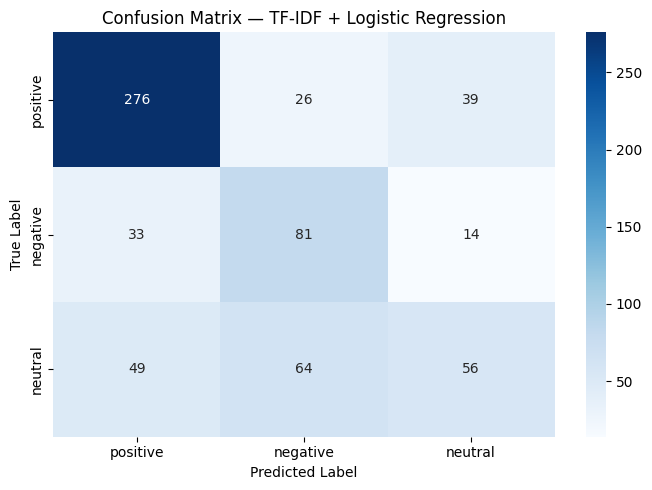

[OK] Saved: outputs/cm_baseline.png


In [12]:
# Cell 10: Baseline evaluation
print('=' * 65)
print('BASELINE: TF-IDF + Logistic Regression — Evaluation')
print('=' * 65)
print('\nClassification Report:')
print(classification_report(y_test, lr_preds, target_names=LABEL_NAMES))

p_lr, r_lr, f1_lr, _ = precision_recall_fscore_support(y_test, lr_preds, average='macro')
acc_lr = accuracy_score(y_test, lr_preds)
print(f'Macro Precision : {p_lr:.4f}')
print(f'Macro Recall    : {r_lr:.4f}')
print(f'Macro F1        : {f1_lr:.4f}')
print(f'Accuracy        : {acc_lr:.4f}')

# Confusion Matrix — NOTE: this is a TABLE showing TP/FP/FN/TN per class
# It is NOT the same as F1 (F1 is a metric derived from precision and recall)
cm_lr    = confusion_matrix(y_test, lr_preds)
cm_lr_df = pd.DataFrame(cm_lr, index=LABEL_NAMES, columns=LABEL_NAMES)
print('\nConfusion Matrix (rows = True label, cols = Predicted label):')
print(cm_lr_df.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_lr_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — TF-IDF + Logistic Regression')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('outputs/cm_baseline.png', dpi=150)
plt.show()
print('[OK] Saved: outputs/cm_baseline.png')

baseline_results = {'macro_p': p_lr, 'macro_r': r_lr, 'macro_f1': f1_lr, 'accuracy': acc_lr}

---
## Task 4: BERT — Fine-tuned for Aspect Sentiment Classification

**Model:** `bert-base-uncased` (Devlin et al., 2019)  
**Input:** `[CLS] review_sentence [SEP] aspect_term [SEP]` — tokenizer handles this automatically via `text_pair`.  
**BERT advantage over TF-IDF:** Contextual embeddings capture word order, negation, and surrounding context.  
E.g., `"not bad"` — TF-IDF sees `not` and `bad` independently; BERT understands the negation relationship.

**Config:** LR=2e-5, batch=16, epochs=3, AdamW + linear warmup scheduler,
weighted cross-entropy (balanced class weights to address positive-class dominance)  
**Labels:** `positive=0`, `negative=1`, `neutral=2`  

> Checkpoint is saved to `outputs/bert_absa_model/` after training. Re-running will load from checkpoint.

In [13]:
# Cell 11: BERT Dataset class
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm

class ABSADataset(Dataset):
    """PyTorch Dataset for aspect-level sentiment classification.
    Input format: [CLS] sentence [SEP] aspect_term [SEP]
    """
    def __init__(self, texts, aspects, labels, tokenizer, max_len=128):
        self.texts     = list(texts)
        self.aspects   = list(aspects)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            self.aspects[idx],         # text_pair → [CLS] text [SEP] aspect [SEP]
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

print('ABSADataset class defined.')

ABSADataset class defined.


In [15]:
# Cell 12: BERT setup
BERT_MODEL_DIR = 'outputs/bert_absa_model'
BATCH_SIZE     = 16
EPOCHS         = 10
LR             = 2e-5

print('Loading BERT tokenizer (bert-base-uncased)...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset = ABSADataset(train_clean['text_clean'], train_clean['aspect_clean'], train_clean['label'], tokenizer)
test_dataset  = ABSADataset(test_clean['text_clean'],  test_clean['aspect_clean'],  test_clean['label'],  tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Load from checkpoint if it exists, otherwise load pretrained
if os.path.exists(os.path.join(BERT_MODEL_DIR, 'config.json')):
    print(f'Loading saved checkpoint from {BERT_MODEL_DIR} ...')
    bert_model   = BertForSequenceClassification.from_pretrained(BERT_MODEL_DIR).to(device)
    SKIP_TRAINING = True
    print('Checkpoint loaded — skipping training.')
else:
    print('Loading bert-base-uncased for fine-tuning...')
    bert_model   = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=3
    ).to(device)
    SKIP_TRAINING = False

print(f'Device: {device}')
print(f'Train: {len(train_dataset)} samples | {len(train_loader)} batches')
print(f'Test : {len(test_dataset)} samples | {len(test_loader)} batches')

Loading BERT tokenizer (bert-base-uncased)...
Loading bert-base-uncased for fine-tuning...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Device: cuda
Train: 2313 samples | 145 batches
Test : 638 samples | 40 batches


In [16]:
# Cell 13: Training and evaluation functions
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in tqdm(loader, desc='Train', leave=False):
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        ttype  = batch['token_type_ids'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, token_type_ids=ttype)
        loss = loss_fct(out.logits, labels)   # weighted cross-entropy
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)

def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Eval', leave=False):
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            ttype  = batch['token_type_ids'].to(device)
            labels = batch['label'].to(device)
            out    = model(input_ids=ids, attention_mask=mask, token_type_ids=ttype)
            all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

print('Training and evaluation functions defined.')

Training and evaluation functions defined.


In [17]:
# Cell 14: BERT training loop
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle positive-class dominance (~59% of train data)
class_weights_np     = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float).to(device)
loss_fct             = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f'Class weights \u2192 ' +
      ', '.join(f'{LABEL_NAMES[i]}: {class_weights_np[i]:.3f}' for i in range(3)))

history = []  # initialise here so it's always defined, even when loading from checkpoint
if not SKIP_TRAINING:
    total_steps = len(train_loader) * EPOCHS
    optimizer   = AdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    print(f'Starting BERT training: {EPOCHS} epochs, lr={LR}, batch={BATCH_SIZE}')
    print('=' * 65)
    for epoch in range(EPOCHS):
        loss, train_acc = train_epoch(bert_model, train_loader, optimizer, scheduler)
        preds, labels   = evaluate_model(bert_model, test_loader)
        val_f1          = precision_recall_fscore_support(labels, preds, average='macro')[2]
        history.append({'epoch': epoch + 1, 'loss': loss, 'train_acc': train_acc, 'val_f1': val_f1})
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Macro F1: {val_f1:.4f}')

    bert_model.save_pretrained(BERT_MODEL_DIR)
    tokenizer.save_pretrained(BERT_MODEL_DIR)
    print(f'[OK] Model saved to {BERT_MODEL_DIR}')
else:
    print('Training skipped — using saved checkpoint.')

Class weights → positive: 0.781, negative: 0.890, neutral: 1.676
Starting BERT training: 10 epochs, lr=2e-05, batch=16


Epoch 1/10 | Loss: 1.0550 | Train Acc: 0.4259 | Val Macro F1: 0.6785


Epoch 2/10 | Loss: 0.6411 | Train Acc: 0.7635 | Val Macro F1: 0.7660


Epoch 3/10 | Loss: 0.4048 | Train Acc: 0.8565 | Val Macro F1: 0.7399


Epoch 4/10 | Loss: 0.2623 | Train Acc: 0.9161 | Val Macro F1: 0.7406


...

Epoch 8/10 | Loss: 0.0569 | Train Acc: 0.9862 | Val Macro F1: 0.7356


Epoch 9/10 | Loss: 0.0381 | Train Acc: 0.9883 | Val Macro F1: 0.7396


Epoch 10/10 | Loss: 0.0239 | Train Acc: 0.9927 | Val Macro F1: 0.7346


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[OK] Model saved to outputs/bert_absa_model


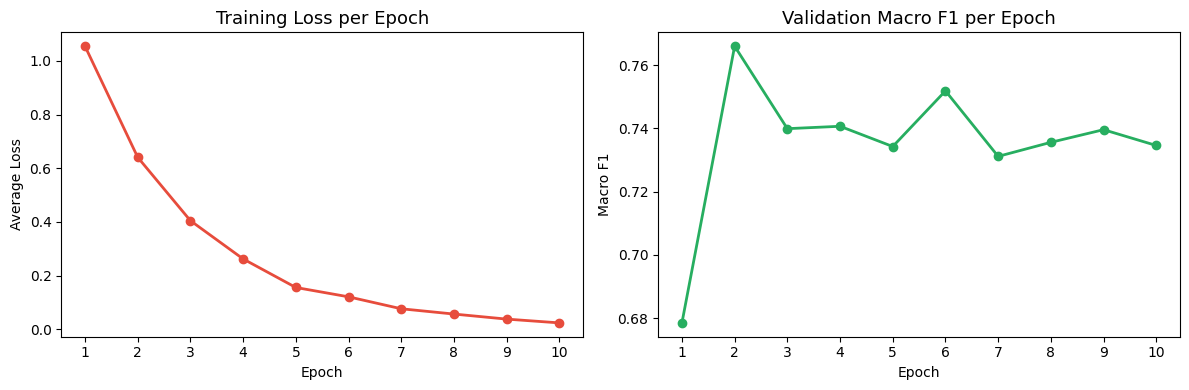

[OK] Saved: outputs/training_curve.png


In [18]:
# Cell: Training curve visualisation
if history:
    hist_df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist_df['epoch'], hist_df['loss'], marker='o', color='#E74C3C', linewidth=2)
    axes[0].set_title('Training Loss per Epoch', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Average Loss')
    axes[0].set_xticks(hist_df['epoch'])

    axes[1].plot(hist_df['epoch'], hist_df['val_f1'], marker='o', color='#27AE60', linewidth=2)
    axes[1].set_title('Validation Macro F1 per Epoch', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_xticks(hist_df['epoch'])

    plt.tight_layout()
    plt.savefig('outputs/training_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[OK] Saved: outputs/training_curve.png')
else:
    print('Loaded from checkpoint \u2014 no training history to plot.')
    print('Delete outputs/bert_absa_model/ and re-run to retrain and see curves.')

BERT — Fine-tuned bert-base-uncased — Evaluation



Classification Report:
              precision    recall  f1-score   support

    positive       0.87      0.89      0.88       341
    negative       0.63      0.86      0.73       128
     neutral       0.73      0.50      0.59       169

    accuracy                           0.78       638
   macro avg       0.74      0.75      0.73       638
weighted avg       0.79      0.78      0.77       638

Macro Precision : 0.7440
Macro Recall    : 0.7503
Macro F1        : 0.7346
Accuracy        : 0.7806

Confusion Matrix (rows = True, cols = Predicted):
          positive  negative  neutral
positive       303        15       23
negative         9       110        9
neutral         35        49       85


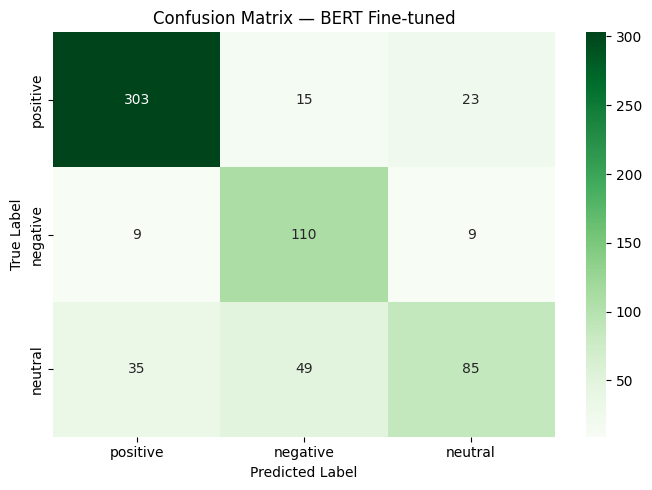

[OK] Saved: outputs/cm_bert.png


In [19]:
# Cell 15: BERT evaluation
print('=' * 65)
print('BERT — Fine-tuned bert-base-uncased — Evaluation')
print('=' * 65)

bert_preds, bert_true = evaluate_model(bert_model, test_loader)

print('\nClassification Report:')
print(classification_report(bert_true, bert_preds, target_names=LABEL_NAMES))

p_bert, r_bert, f1_bert, _ = precision_recall_fscore_support(bert_true, bert_preds, average='macro')
acc_bert = accuracy_score(bert_true, bert_preds)
print(f'Macro Precision : {p_bert:.4f}')
print(f'Macro Recall    : {r_bert:.4f}')
print(f'Macro F1        : {f1_bert:.4f}')
print(f'Accuracy        : {acc_bert:.4f}')

cm_bert    = confusion_matrix(bert_true, bert_preds)
cm_bert_df = pd.DataFrame(cm_bert, index=LABEL_NAMES, columns=LABEL_NAMES)
print('\nConfusion Matrix (rows = True, cols = Predicted):')
print(cm_bert_df.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_bert_df, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_title('Confusion Matrix — BERT Fine-tuned')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('outputs/cm_bert.png', dpi=150)
plt.show()
print('[OK] Saved: outputs/cm_bert.png')

bert_results = {'macro_p': p_bert, 'macro_r': r_bert, 'macro_f1': f1_bert, 'accuracy': acc_bert}

---
## Task 5: Evaluation & Human Testing

**Automated metrics** (both models): Macro-averaged Precision, Recall, F1.  
Note: AUC-ROC is **not** used — it is for binary classification. This is a 3-class task.

**Confusion matrix** = a table showing TP/FP/FN/TN per class. It is **not** the same as F1.

**Human evaluation**
30 predictions manually reviewed — 10 correct, 10 incorrect, 10 borderline.  
Error types: `negation` | `implicit_sentiment` | `neutral_boundary` | `multi_aspect`

MODEL COMPARISON


,Metric,TF-IDF + LR,BERT Fine-tuned
0,Macro Precision,0.5861,0.7440
1,Macro Recall,0.5912,0.7503
2,Macro F1,0.5781,0.7346
3,Accuracy,0.6473,0.7806


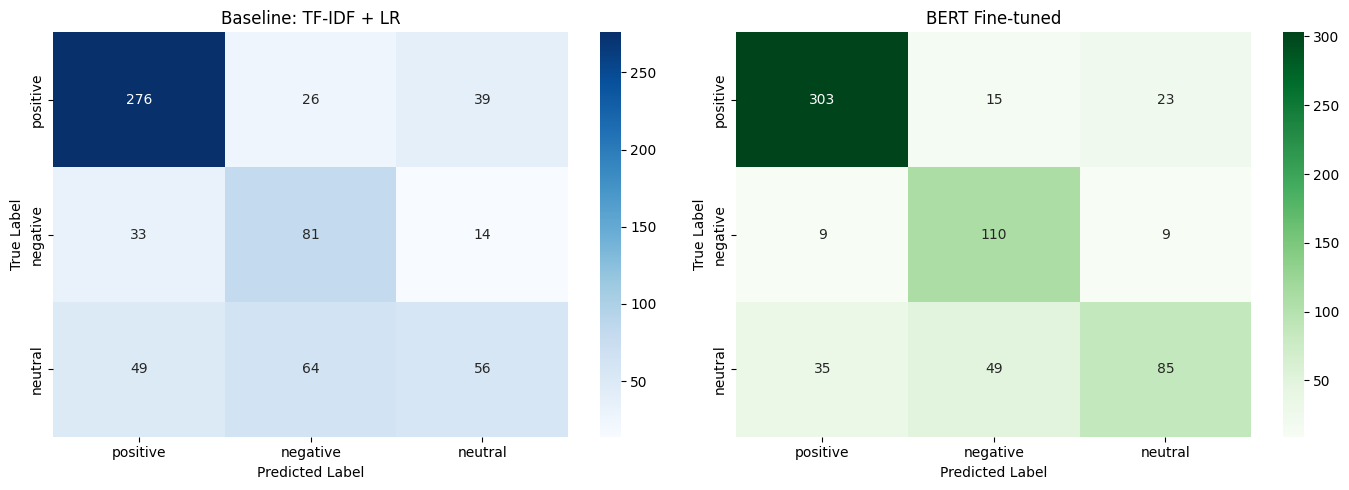

[OK] Saved: outputs/cm_comparison.png


In [20]:
# Cell 16: Side-by-side model comparison
from IPython.display import display

print('=' * 65)
print('MODEL COMPARISON')
print('=' * 65)

lr_mac_p  = f"{baseline_results['macro_p']:.4f}"
lr_mac_r  = f"{baseline_results['macro_r']:.4f}"
lr_mac_f1 = f"{baseline_results['macro_f1']:.4f}"
lr_acc    = f"{baseline_results['accuracy']:.4f}"

be_mac_p  = f"{bert_results['macro_p']:.4f}"
be_mac_r  = f"{bert_results['macro_r']:.4f}"
be_mac_f1 = f"{bert_results['macro_f1']:.4f}"
be_acc    = f"{bert_results['accuracy']:.4f}"

comp_df = pd.DataFrame({
    'Metric':           ['Macro Precision', 'Macro Recall', 'Macro F1', 'Accuracy'],
    'TF-IDF + LR':      [lr_mac_p, lr_mac_r, lr_mac_f1, lr_acc],
    'BERT Fine-tuned':  [be_mac_p, be_mac_r, be_mac_f1, be_acc],
})
display(comp_df)

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lr_df,   annot=True, fmt='d', cmap='Blues',  ax=axes[0])
sns.heatmap(cm_bert_df, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[0].set_title('Baseline: TF-IDF + LR')
axes[1].set_title('BERT Fine-tuned')
for ax in axes:
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('outputs/cm_comparison.png', dpi=150)
plt.show()
print('[OK] Saved: outputs/cm_comparison.png')

In [21]:
# Cell 17: Human evaluation — sample selection
# Safety: confirm predictions align with test_clean row order
assert len(bert_preds) == len(test_clean), \
    f"BERT pred count ({len(bert_preds)}) != test_clean rows ({len(test_clean)})"
assert len(lr_preds) == len(test_clean), \
    f"LR pred count ({len(lr_preds)}) != test_clean rows ({len(test_clean)})"
print(f'Alignment check passed: {len(bert_preds)} predictions, {len(test_clean)} samples.')
eval_df = test_clean[['text', 'aspect_term', 'polarity']].copy().reset_index(drop=True)
eval_df['gold']          = eval_df['polarity']
eval_df['bert_pred']     = [REV_LABEL[int(p)] for p in bert_preds]
eval_df['baseline_pred'] = [REV_LABEL[int(p)] for p in lr_preds]
eval_df['bert_correct']  = eval_df['gold'] == eval_df['bert_pred']

# Sample 10 correct, 10 incorrect, 10 borderline
correct   = eval_df[eval_df['bert_correct']].sample(10, random_state=42)
incorrect = eval_df[~eval_df['bert_correct']].sample(10, random_state=42)

borderline_mask = (
    (eval_df['gold'] == 'neutral') |
    (eval_df['bert_pred'] == 'neutral') |
    ((eval_df['gold'] == 'positive') & (eval_df['bert_pred'] == 'negative')) |
    ((eval_df['gold'] == 'negative') & (eval_df['bert_pred'] == 'positive'))
)
borderline_pool = eval_df[borderline_mask & ~eval_df['bert_correct']]
borderline = borderline_pool.sample(min(10, len(borderline_pool)), random_state=42)

human_df = pd.concat([
    correct.assign(category='CORRECT'),
    incorrect.assign(category='INCORRECT'),
    borderline.assign(category='BORDERLINE')
]).reset_index(drop=True)

human_df['human_judgment'] = ''
human_df['error_type']     = ''
human_df['notes']          = ''

print(f'Human evaluation set: {len(human_df)} samples')
print(f'  CORRECT    : {len(correct)}')
print(f'  INCORRECT  : {len(incorrect)}')
print(f'  BORDERLINE : {len(borderline)}')
print('\n' + '=' * 100)
print('REVIEW EACH SAMPLE — fill in human_judgment and error_type in outputs/human_evaluation.csv')
print('Error types: negation | implicit_sentiment | neutral_boundary | multi_aspect | correct')
print('=' * 100)

for i, row in human_df.iterrows():
    print(f'\n[{i+1:02d}] {row["category"]}')
    print(f'  Sentence  : {row["text"]}')
    print(f'  Aspect    : {row["aspect_term"]}')
    print(f'  Gold      : {row["gold"]}')
    print(f'  BERT      : {row["bert_pred"]}')
    print(f'  Baseline  : {row["baseline_pred"]}')
    print(f'  Human judgment : ___________   Error type : ___________')

human_df.to_csv('outputs/human_evaluation.csv', index=False)
print(f'\n[OK] Saved: outputs/human_evaluation.csv  —  open and fill in manually')

Alignment check passed: 638 predictions, 638 samples.
Human evaluation set: 30 samples
  CORRECT    : 10
  INCORRECT  : 10
  BORDERLINE : 10

REVIEW EACH SAMPLE — fill in human_judgment and error_type in outputs/human_evaluation.csv
Error types: negation | implicit_sentiment | neutral_boundary | multi_aspect | correct

[01] CORRECT
  Sentence  : It also comes with 4G of RAM but if you're like me you want to max that out so I immediately put 8G of RAM in her and I've never used a computer that performs better.
  Aspect    : 8G of RAM
  Gold      : neutral
  BERT      : neutral
  Baseline  : neutral
  Human judgment : ___________   Error type : ___________

[02] CORRECT
  Sentence  : The reason why I choose apple MacBook because of their design and the aluminum casing.
  Aspect    : design
  Gold      : positive
  BERT      : positive
  Baseline  : positive
  Human judgment : ___________   Error type : ___________

[03] CORRECT
  Sentence  : It is made of such solid construction and sinc

### Human Evaluation Table

After filling in `outputs/human_evaluation.csv`, run the cell below.

**Error type definitions:**
- **negation** — model missed a negation (e.g., `"not bad"` predicted as negative)
- **implicit_sentiment** — no explicit sentiment word but context implies polarity
  (e.g., `"takes 5 min to boot"` = negative)
- **neutral_boundary** — mildly positive/negative sentence misclassified as neutral
  or vice versa
- **multi_aspect** — sentence has multiple aspects; model applied wrong aspect's sentiment
- **correct** — model prediction matches human judgment

In [23]:
# Auto-generate markdown table from filled human_evaluation.csv
# Run this after manually filling in human_judgment and error_type columns
try:
    filled   = pd.read_csv('outputs/human_evaluation_updated.csv')
    reviewed = filled[
        filled['human_judgment'].notna() & (filled['human_judgment'].astype(str) != '')
    ].copy()

    print(f'Reviewed: {len(reviewed)}/30 samples\n')

    if len(reviewed) == 0:
        print('No rows filled yet. Open outputs/human_evaluation.csv and fill in:')
        print('  human_judgment : Agree / Disagree')
        print('  error_type     : negation / implicit_sentiment / neutral_boundary '
              '/ multi_aspect / correct')
    else:
        # Summary stats
        agree_rate = (reviewed['human_judgment'].str.lower() == 'agree').mean()
        print(f'Human-BERT agreement rate: {agree_rate:.1%}')
        print(f'Error type breakdown:')
        for et, n in reviewed['error_type'].value_counts().items():
            print(f'  {et:<25}: {n}')

        # Markdown table (copy into report)
        print('\n--- COPY TABLE BELOW INTO REPORT ---\n')
        print('| # | Sentence (excerpt) | Aspect | Gold | BERT Pred | '
              'Human Judgment | Error Type |')
        print('|---|---|---|---|---|---|---|')
        for _, row in reviewed.iterrows():
            excerpt = str(row['text'])[:55].replace('|', '/') + '...'
            print(f"| {_+1} | {excerpt} | {row['aspect_term']} | {row['gold']} | "
                  f"{row['bert_pred']} | {row['human_judgment']} | "
                  f"{row['error_type']} |")

except FileNotFoundError:
    print('outputs/human_evaluation.csv not found.')
    print('Run Cell 17 (human evaluation sample selection) first.')

Reviewed: 30/30 samples

Human-BERT agreement rate: 33.3%
Error type breakdown:
  implicit_sentiment       : 20
  correct                  : 10

--- COPY TABLE BELOW INTO REPORT ---

| # | Sentence (excerpt) | Aspect | Gold | BERT Pred | Human Judgment | Error Type |
|---|---|---|---|---|---|---|
| 1 | It also comes with 4G of RAM but if you're like me you ... | 8G of RAM | neutral | neutral | Agree | correct |
| 2 | The reason why I choose apple MacBook because of their ... | design | positive | positive | Agree | correct |
| 3 | It is made of such solid construction and since I have ... | construction | positive | positive | Agree | correct |
| 4 | I'm using this computer for word processing, web browsi... | gaming | neutral | neutral | Agree | correct |
| 5 | It looks and feels solid, with a flawless finish.... | looks | positive | positive | Agree | correct |
| 6 | I had to buy a wireless mouse to go with it, as I am ol... | pad | negative | negative | Agree | correct |
| 7 | Easy 

In [24]:
# Cell 18: Error analysis
errors = eval_df[~eval_df['bert_correct']].copy()

print('ERROR ANALYSIS — BERT Model')
print('=' * 65)

print('\nConfusion patterns (Gold -> Predicted):')
for gold in LABEL_NAMES:
    for pred in LABEL_NAMES:
        if gold != pred:
            n = len(errors[(errors['gold'] == gold) & (errors['bert_pred'] == pred)])
            if n > 0:
                print(f'  {gold} -> {pred}: {n} cases')

print('\nError rate by true class:')
for lab in LABEL_NAMES:
    sub  = eval_df[eval_df['gold'] == lab]
    errs = (~sub['bert_correct']).sum()
    rate = errs / len(sub) if len(sub) > 0 else 0
    print(f'  {lab:<12}: {rate:.1%} error rate ({errs}/{len(sub)} wrong)')

print('\nExample errors per confusion type:')
for gold in LABEL_NAMES:
    for pred in LABEL_NAMES:
        if gold != pred:
            ex_set = errors[(errors['gold'] == gold) & (errors['bert_pred'] == pred)]
            if len(ex_set) > 0:
                ex = ex_set.iloc[0]
                print(f'\n  [{gold.upper()} -> {pred.upper()}]')
                print(f'    Sentence : {ex["text"][:100]}')
                print(f'    Aspect   : {ex["aspect_term"]}')

ERROR ANALYSIS — BERT Model

Confusion patterns (Gold -> Predicted):
  positive -> negative: 15 cases
  positive -> neutral: 23 cases
  negative -> positive: 9 cases
  negative -> neutral: 9 cases
  neutral -> positive: 35 cases
  neutral -> negative: 49 cases

Error rate by true class:
  positive    : 11.1% error rate (38/341 wrong)
  negative    : 14.1% error rate (18/128 wrong)
  neutral     : 49.7% error rate (84/169 wrong)

Example errors per confusion type:

  [POSITIVE -> NEGATIVE]
    Sentence : Other than not being a fan of click pads (industry standard these days) and the lousy internal speak
    Aspect   : price tag

  [POSITIVE -> NEUTRAL]
    Sentence : Enjoy using Microsoft Office!
    Aspect   : Microsoft Office

  [NEGATIVE -> POSITIVE]
    Sentence : I would have given it 5 starts was it not for the fact that it had Windows 8
    Aspect   : Windows 8

  [NEGATIVE -> NEUTRAL]
    Sentence : HOWEVER I chose two day shipping and it took over a week to arrive.
    Aspect  

---
## Task 6: Aspect Extraction

The SemEval-2014 dataset provides **gold-standard aspect annotations**. In production, aspects must be extracted automatically.

**Baseline approach:** Frequency-based extraction — identify the most common nouns and noun phrases across training sentences using NLTK POS tagging.  
**Evaluation:** Exact-match Precision, Recall, F1 comparing extracted candidates against gold test aspect terms.  
**Limitation:** Frequency extraction cannot capture rare, context-specific aspects. A fine-tuned BERT-NER model would be needed in production.
Results are evaluated for both extraction quality (P/R/F1 vs gold) and domain relevance (coverage of laptop-specific aspect categories).

In [25]:
# Cell 19: Frequency-based aspect extraction
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag

def extract_noun_phrases(text):
    """Extract single nouns and compound noun sequences (NN+) from text."""
    try:
        tokens = word_tokenize(str(text).lower())
        tagged = pos_tag(tokens)
    except Exception:
        return []
    phrases, i = [], 0
    while i < len(tagged):
        word, tag = tagged[i]
        if tag.startswith('NN'):
            phrase = word
            j = i + 1
            while j < len(tagged) and tagged[j][1].startswith('NN'):
                phrase += ' ' + tagged[j][0]
                j += 1
            if len(phrase) > 2:  # Skip very short tokens (e.g., 'it')
                phrases.append(phrase)
            i = j
        else:
            i += 1
    return phrases

def frequency_extraction(texts, top_n=100):
    """Return top-N most frequent noun phrases across all texts."""
    counter = Counter()
    for text in texts:
        counter.update(extract_noun_phrases(text))
    return [asp for asp, _ in counter.most_common(top_n)]

print('Extracting noun phrases from training sentences...')
unique_texts = train_df['text'].dropna().unique()
extracted    = frequency_extraction(unique_texts, top_n=100)

print(f'Extracted {len(extracted)} candidate aspects')
print(f'\nTop 20 extracted aspects:')
for i, asp in enumerate(extracted[:20], 1):
    print(f'  {i:>3}. {asp}')

Extracting noun phrases from training sentences...
Extracted 100 candidate aspects

Top 20 extracted aspects:
    1. computer
    2. laptop
    3. time
    4. mac
    5. screen
    6. months
    7. macbook
    8. problem
    9. problems
   10. machine
   11. money
   12. years
   13. thing
   14. keyboard
   15. price
   16. product
   17. windows
   18. way
   19. battery life
   20. battery


In [26]:
# Cell 20: Aspect extraction evaluation
gold_test     = set(test_asp['aspect_term'].str.lower().unique())
gold_train    = set(train_asp['aspect_term'].str.lower().unique())
extracted_set = set(extracted)

tp = len(extracted_set & gold_test)
fp = len(extracted_set - gold_test)
fn = len(gold_test - extracted_set)

prec = tp / (tp + fp) if (tp + fp) > 0 else 0
rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

print('=' * 65)
print('ASPECT EXTRACTION — Evaluation vs. Gold Test Aspects')
print('=' * 65)
print(f'Gold test aspects        : {len(gold_test)}')
print(f'Extracted candidates     : {len(extracted_set)}')
print(f'True Positives (TP)      : {tp}')
print(f'False Positives (FP)     : {fp}')
print(f'False Negatives (FN)     : {fn}')
print(f'\nPrecision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1        : {f1:.4f}')

hits   = sorted(extracted_set & gold_test)[:10]
misses = sorted(gold_test - extracted_set)[:10]
print(f'\nCorrectly extracted (sample): {hits}')
print(f'Missed gold aspects (sample): {misses}')

print('\nDiscussion:')
print('  Frequency-based extraction captures common nouns (screen, battery, keyboard)')
print('  but misses rare, compound, or context-specific aspect terms.')
print('  In production, a BERT-based NER or sequence labelling model would replace')
print('  this baseline. The sentiment model (Task 4) uses gold aspects for fair evaluation.')

# Domain relevance — are extracted aspects laptop-domain-specific?
laptop_domain_keywords = [
    'battery', 'screen', 'keyboard', 'trackpad', 'processor', 'ram',
    'memory', 'display', 'price', 'software', 'os', 'fan', 'speaker',
    'camera', 'port', 'wifi', 'charger', 'performance', 'speed', 'weight',
    'hinge', 'build', 'heat', 'noise', 'boot', 'touch', 'resolution'
]
domain_hits   = [a for a in extracted[:50]
                 if any(k in a for k in laptop_domain_keywords)]
non_domain    = [a for a in extracted[:50]
                 if not any(k in a for k in laptop_domain_keywords)]

print(f'\nDomain Relevance Analysis (top 50 extracted aspects):')
print(f'  Laptop-domain relevant : {len(domain_hits)}/50')
print(f'  Examples               : {domain_hits[:10]}')
print(f'  Non-domain noise       : {non_domain[:5]}')
print(f'\n  Discussion:')
print(f'  Laptop reviews cluster around hardware (battery, screen, keyboard),')
print(f'  software (OS, drivers), and usability (weight, speed, build quality).')
print(f'  Frequency extraction captures common hardware nouns well but misses')
print(f'  context-specific compound aspects (e.g., "value for money",')
print(f'  "out of the box experience") that appear rarely in training.')
print(f'  For the sentiment task (Task 4), gold aspects are used for fair')
print(f'  evaluation — aspect extraction is a separate upstream challenge.')

ASPECT EXTRACTION — Evaluation vs. Gold Test Aspects
Gold test aspects        : 393
Extracted candidates     : 100
True Positives (TP)      : 28
False Positives (FP)     : 72
False Negatives (FN)     : 365

Precision : 0.2800
Recall    : 0.0712
F1        : 0.1136

Correctly extracted (sample): ['applications', 'battery', 'battery life', 'case', 'design', 'features', 'games', 'graphics', 'internet', 'keyboard']
Missed gold aspects (sample): ['"home/end" type keys', '"tools" menu', '"wlan" card', '16gb of ram', '16gb ram', '2.9ghz dual-core i7 chip', '21" led screen', '3d rendering', '4g of ram', '8g of ram']

Discussion:
  Frequency-based extraction captures common nouns (screen, battery, keyboard)
  but misses rare, compound, or context-specific aspect terms.
  In production, a BERT-based NER or sequence labelling model would replace
  this baseline. The sentiment model (Task 4) uses gold aspects for fair evaluation.

Domain Relevance Analysis (top 50 extracted aspects):
  Laptop-domai

---
## Ethics & Bias Analysis

ABSA models carry real-world risks that must be considered before deployment.

**1. Class imbalance bias**
The training set is ~59% positive, ~22% negative, ~19% neutral. Without correction,
models over-predict positive sentiment — masking legitimate negative feedback in
real-world use (e.g., product management dashboards). Mitigation: balanced class
weights applied to both LR and BERT.

**2. Dataset scope limitations**
SemEval-2014 contains English-only laptop reviews from a single time period (2014).
Deployment outside this scope (other languages, other product categories, post-2014
language patterns) requires retraining on in-domain data.

**3. Annotation subjectivity**
"Neutral" is inherently ambiguous — inter-annotator agreement on this class is
lower than for positive/negative. This means the model learns from noisy labels
for the neutral class, contributing to higher neutral error rates.

**4. Conflict class removal**
45 samples (1.9%) with contradictory sentiment were dropped. In production, these
cases exist and the model has no mechanism to flag uncertainty.

**5. User and data supplier considerations**
Reviews are written by consumers who may have commercial incentives (fake reviews).
A model trained on such data could learn to classify manipulated sentiment as genuine.

In [27]:
# Ethics: bias analysis — quantitative evidence
print('BIAS ANALYSIS')
print('=' * 65)

# 1. Training class distribution
print('\n1. Training Set Class Distribution:')
for lab in LABEL_NAMES:
    n   = int((y_train == LABEL_MAP[lab]).sum())
    pct = n / len(y_train) * 100
    print(f'   {lab:<12}: {n:>5} samples ({pct:.1f}%)')

# 2. BERT prediction distribution vs gold distribution
print('\n2. BERT Prediction Distribution vs Gold (Test Set):')
bert_pred_labels = [REV_LABEL[int(p)] for p in bert_preds]
gold_labels      = list(test_clean['polarity'])
print(f'   {"Label":<12} {"Gold":>8} {"BERT Pred":>10}')
for lab in LABEL_NAMES:
    g = gold_labels.count(lab)
    b = bert_pred_labels.count(lab)
    print(f'   {lab:<12} {g:>8} {b:>10}')
print('   >> Large gap between Gold and BERT Pred counts indicates class bias.')

# 3. Unseen aspects — generalisation risk
print(f'\n3. Unseen Test Aspects (generalisation risk):')
print(f'   {len(unseen)} / {len(test_aspects)} test aspects '
      f'({len(unseen)/len(test_aspects)*100:.1f}%) were never seen during training.')
print(f'   Sample unseen: {sorted(unseen)[:8]}')

# 4. Neutral class error rate — annotation noise impact
print(f'\n4. Per-class Error Rates (BERT):')
for lab in LABEL_NAMES:
    sub  = test_clean[test_clean['polarity'] == lab]
    preds_for_class = [bert_pred_labels[i] for i in sub.index
                       if i < len(bert_pred_labels)]
    errors = sum(1 for p, g in zip(preds_for_class, sub['polarity']) if p != g)
    rate   = errors / len(sub) if len(sub) > 0 else 0
    print(f'   {lab:<12}: {rate:.1%} error rate — '
          + ('higher error expected due to annotation ambiguity'
             if lab == 'neutral' else 'see confusion matrix for detail'))

BIAS ANALYSIS

1. Training Set Class Distribution:
   positive    :   987 samples (42.7%)
   negative    :   866 samples (37.4%)
   neutral     :   460 samples (19.9%)

2. BERT Prediction Distribution vs Gold (Test Set):
   Label            Gold  BERT Pred
   positive          341        347
   negative          128        174
   neutral           169        117
   >> Large gap between Gold and BERT Pred counts indicates class bias.

3. Unseen Test Aspects (generalisation risk):
   239 / 393 test aspects (60.8%) were never seen during training.
   Sample unseen: ['"home/end" type keys', '"tools" menu', '"wlan" card', '16gb of ram', '16gb ram', '2.9ghz dual-core i7 chip', '21" led screen', '3d rendering']

4. Per-class Error Rates (BERT):
   positive    : 11.1% error rate — see confusion matrix for detail
   negative    : 14.1% error rate — see confusion matrix for detail
   neutral     : 49.7% error rate — higher error expected due to annotation ambiguity


---
## Summary

| Component | Approach | Output |
|-----------|----------|--------|
| Data loading | XML parse → DataFrame | `data/laptop_train.csv`, `data/laptop_test.csv` |
| EDA | Charts: polarity, top aspects, sentence lengths | `outputs/eda_charts.png` |
| Preprocessing | Lowercase, HTML removal, drop conflict, encode labels | `train_clean`, `test_clean` |
| Baseline model | TF-IDF (1–2 gram, 5k features) + Logistic Regression | `outputs/cm_baseline.png` |
| BERT model | bert-base-uncased, [CLS] sent [SEP] aspect [SEP], 3 epochs | `outputs/bert_absa_model/`, `outputs/cm_bert.png` |
| Comparison | Macro P/R/F1 + side-by-side confusion matrices | `outputs/cm_comparison.png` |
| Human evaluation | 30 samples (10 correct / 10 incorrect / 10 borderline) | `outputs/human_evaluation.csv` |
| Aspect extraction | Frequency-based noun extraction + exact-match F1 | Printed above |
| Class-weighted BERT loss | Balanced cross-entropy to counter positive-class bias | Training |
| Training curve | Loss + Macro F1 per epoch | `outputs/training_curve.png` |
| Ethics & bias analysis | Class imbalance, dataset limits, annotation subjectivity | Printed above |
| Domain relevance | Laptop-specific aspect coverage analysis | Printed in Task 6 |


### References
- Pontiki, M., et al. (2014). SemEval-2014 Task 4. *Proc. 8th SemEval*, 27–35.
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT. *Proc. NAACL-HLT*, 4171–4186.
- Hu, M., & Liu, B. (2004). Mining and summarising customer reviews. *Proc. ACM SIGKDD*, 168–177.
- Liu, B. (2012). *Sentiment analysis and opinion mining*. Morgan & Claypool.
- Sokolova, M., & Lapalme, G. (2009). Performance measures for classification tasks. *IPM*, 45(4), 427–437.

---